<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Semanal Nº7: Filtrado digital lineal de ECG
#### Ivana Rocio Miranda

## Introducción

El electrocardiograma (ECG) es una señal bioeléctrica que refleja la actividad eléctrica del corazón. Su ancho de banda clínicamente relevante se extiende aproximadamente desde **0.5 Hz hasta 35 Hz**, abarcando las ondas P, el complejo QRS y la onda T.

Durante el registro, el ECG queda contaminado por diversas fuentes de ruido:

- **Ruido de alta frecuencia**: causado por el movimiento de los electrodos y la actividad muscular (EMG), que introduce componentes por encima de los ~35–40 Hz.
- **Deriva de línea de base (wandering baseline)**: debida principalmente al movimiento respiratorio y al movimiento del paciente, que introduce componentes de muy baja frecuencia (por debajo de ~0.5 Hz).

Para mitigar estas interferencias se diseñan filtros digitales **pasa-banda**, que dejan pasar únicamente el rango de interés clínico atenuando el resto. En este trabajo se comparan implementaciones **IIR** (Butterworth) y **FIR** (ventana rectangular, cuadrados mínimos y Parks-McClellan/Remez).

### Filtros IIR vs FIR

| Característica | IIR | FIR |
|---|---|---|
| Fase | No lineal | Lineal (simétrico) |
| Orden típico | Bajo | Alto |
| Estabilidad | Depende del diseño | Siempre estable |
| Implementación | `sosfiltfilt` (zero-phase) | `lfilter` + corrección de retardo |

El uso de `sosfiltfilt` en el filtro IIR aplica el filtro en ambas direcciones, obteniendo **fase cero** a costa de filtrar dos veces, por lo que los requisitos de ripple/atenuación se dividen a la mitad en el diseño.

---


## a) Plantilla de diseño

Se define una plantilla de diseño **pasa-banda** basada en el ancho de banda estimado del ECG. Los parámetros de la plantilla son:

- **Ripple máximo en banda de paso**: 1 dB  
- **Atenuación mínima en bandas de stop**: 40 dB  
- **Banda de stop baja**: 0 → 0.05 Hz (deriva de línea de base)  
- **Banda de paso**: 0.5 Hz → 35 Hz  
- **Banda de stop alta**: 45 Hz → Nyquist 

La figura de la plantilla muestra las regiones prohibidas (sombreadas) que el filtro debe respetar.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import scipy.io as sio

#%% Parametros del filtro

fs = 1000      # Frecuencia de muestreo en Hz

gpass = 1      # Atenuacion maxima permitida en banda de paso [dB]
gstop = 40     # Atenuacion minima requerida en banda de stop [dB]

# Plantilla pasa banda
ws1 = 0.05     # Banda de stop baja
wp1 = 0.5      # Inicio banda de paso
wp2 = 35       # Fin banda de paso
ws2 = 45       # Banda de stop alta

wp = [wp1, wp2]
ws = [ws1, ws2]

print("=== PLANTILLA DE DISEÑO ===")
print(f"Ripple en banda de paso : {gpass} dB")
print(f"Atenuacion en banda stop: {gstop} dB")
print(f"Banda de stop baja      : 0 – {ws1} Hz")
print(f"Banda de paso           : {wp1} – {wp2} Hz")
print(f"Banda de stop alta      : {ws2} – {fs/2} Hz")


=== PLANTILLA DE DISEÑO ===
Ripple en banda de paso : 1 dB
Atenuacion en banda stop: 40 dB
Banda de stop baja      : 0 – 0.05 Hz
Banda de paso           : 0.5 – 35 Hz
Banda de stop alta      : 45 – 500.0 Hz


## b) ¿Cómo se obtuvieron los valores de la plantilla?

En la actividad previa se estimó que el 99 % de la energía de la señal de ECG se encuentra contenida dentro de un ancho de banda de aproximadamente 31.25 Hz. Por este motivo, la frecuencia de corte superior de la banda de paso se eligió ligeramente por encima de dicho valor (wp2 = 35 Hz), de modo de preservar prácticamente toda la información útil de la señal sin introducir una atenuación significativa sobre sus componentes de interés. Asimismo, la banda de rechazo superior se fijó en ws2 = 45 Hz para dejar una banda de transición de 10 Hz que permita implementar un filtro realizable.

Se seleccionó una frecuencia de paso inferior de wp1 = 0.5 Hz y una frecuencia de rechazo inferior de ws1 = 0.05 Hz con el objetivo de atenuar las componentes de muy baja frecuencia (como la deriva de línea de base) preservando las variaciones lentas propias del ECG. La diferencia entre ambas frecuencias proporciona una banda de transición adecuada para el diseño del filtro.


## c) Diseño de filtros

### c.1) Filtro IIR – Butterworth

El filtro de Butterworth es de **módulo de máxima planicidad**: maximiza la planitud de la respuesta en frecuencia en la banda de paso. No presenta rizado ni en la banda de paso ni en la de stop, pero requiere mayor orden que Chebyshev o Cauer para la misma especificación.

Se implementa con `sosfiltfilt`, que aplica el filtro en ambas direcciones (ida y vuelta) obteniendo **fase cero** y sin distorsión de fase en el ECG. Como consecuencia, los parámetros de ripple y atenuación se dividen a la mitad en el diseño (`gpass/2`, `gstop/2`).


In [28]:
#%% Diseño del filtro Butterworth IIR

# Como usamos sosfiltfilt, diseñamos con gpass/2 y gstop/2
# porque filtfilt aplica el filtro dos veces.
ws1but = 0.1     # Banda de stop baja
wp1but = 0.5      # Inicio banda de paso
wp2but = 35       # Fin banda de paso
ws2but = 45       # Banda de stop alta
wpbut = [wp1, wp2]
wsbut = [ws1, ws2]
sos_but = sig.iirdesign(
    wpbut,
    wsbut,
    gpass/2,
    gstop,
    fs=fs,
    analog=False,
    ftype='butter',
    output='sos'
)

print("Filtro IIR Butterworth diseñado correctamente.")
print(f"Número de secciones de segundo orden: {sos_but.shape[0]}")


Filtro IIR Butterworth diseñado correctamente.
Número de secciones de segundo orden: 22


### c.2) Grilla de frecuencia personalizada

Para evaluar la respuesta en frecuencia con alta resolución en las zonas críticas (transiciones, banda de paso) se construye una grilla no uniforme de puntos de frecuencia.


In [29]:
#%% Grilla personalizada de frecuencia

ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500),
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs/2, num=50)
])

ww = np.unique(ww)
ww = ww[ww <= fs/2]

print(f"Grilla de frecuencia: {len(ww)} puntos de evaluación.")


Grilla de frecuencia: 1050 puntos de evaluación.


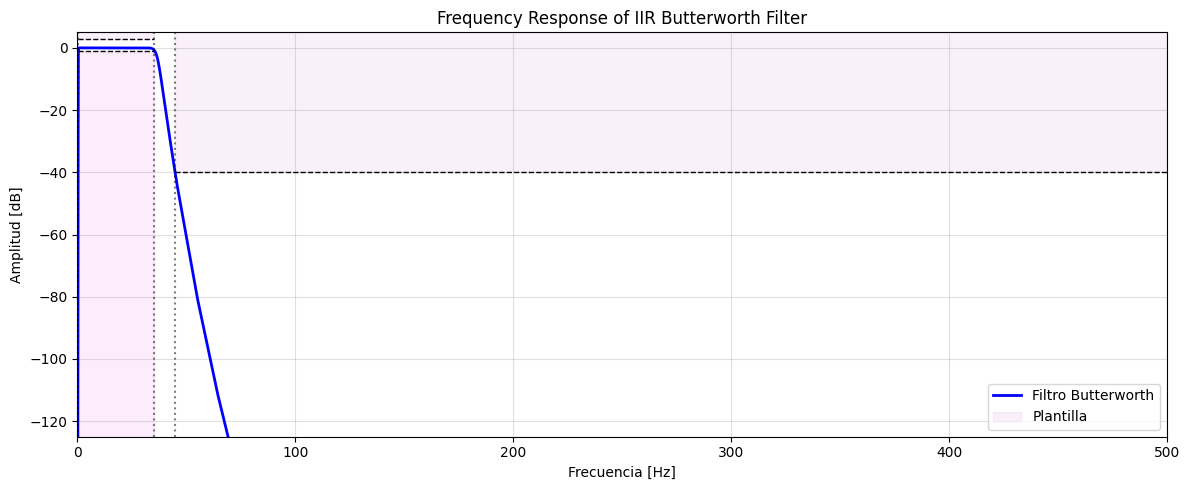

In [30]:
#%% Respuesta en frecuencia del filtro IIR Butterworth

# Calcular la respuesta en frecuencia
w, h = sig.sosfreqz(sos_but, worN=ww, fs=fs)

# Magnitud en dB
modulo_db = 20 * np.log10(np.abs(h) + 1e-12)
fig, ax = plt.subplots(figsize=(12, 5), tight_layout=True)

ax.set_title("Frequency Response of IIR Butterworth Filter")

# Respuesta del filtro
ax.plot(w, modulo_db, 'b', linewidth=2, label='Filtro Butterworth')

piso_grafico = -125
techo_grafico = 5

# Banda de parada inferior
ax.fill_between([0, ws1], -gstop, techo_grafico,
                color='plum', alpha=0.15, label='Plantilla')
ax.plot([0, ws1], [-gstop, -gstop], 'k--', linewidth=1)

# Banda de paso
ax.fill_between([wp1, wp2], piso_grafico, -gpass,
                color='violet', alpha=0.15)
ax.plot([wp1, wp2], [-gpass, -gpass], 'k--', linewidth=1)

ax.fill_between([wp1, wp2], 3, techo_grafico,
                color='plum', alpha=0.15)
ax.plot([wp1, wp2], [3, 3], 'k--', linewidth=1)

# Banda de parada superior
ax.fill_between([ws2, fs/2], -gstop, techo_grafico,
                color='plum', alpha=0.15)
ax.plot([ws2, fs/2], [-gstop, -gstop], 'k--', linewidth=1)

# Líneas verticales de referencia
ax.axvline(ws1, color='k', linestyle=':', alpha=0.5)
ax.axvline(wp1, color='k', linestyle=':', alpha=0.5)
ax.axvline(wp2, color='k', linestyle=':', alpha=0.5)
ax.axvline(ws2, color='k', linestyle=':', alpha=0.5)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Amplitud [dB]")
ax.set_xlim(0, fs/2)
ax.set_ylim(piso_grafico, techo_grafico)

ax.grid(True, which='both', alpha=0.4)
ax.legend(loc='lower right')

plt.show()

### c.3) Filtro FIR – Ventana Rectangular

El método de **ventana** consiste en truncar la respuesta impulsiva ideal del filtro deseado con una función de ventana. La ventana rectangular es la más simple: maximiza la selectividad (transición abrupta) pero introduce el mayor rizado de Gibbs (~9% en amplitud). 

Con `numtaps = 2000` coeficientes se obtiene un orden 1999 con retardo de grupo constante de 999.5 muestras, que se compensa al graficar.


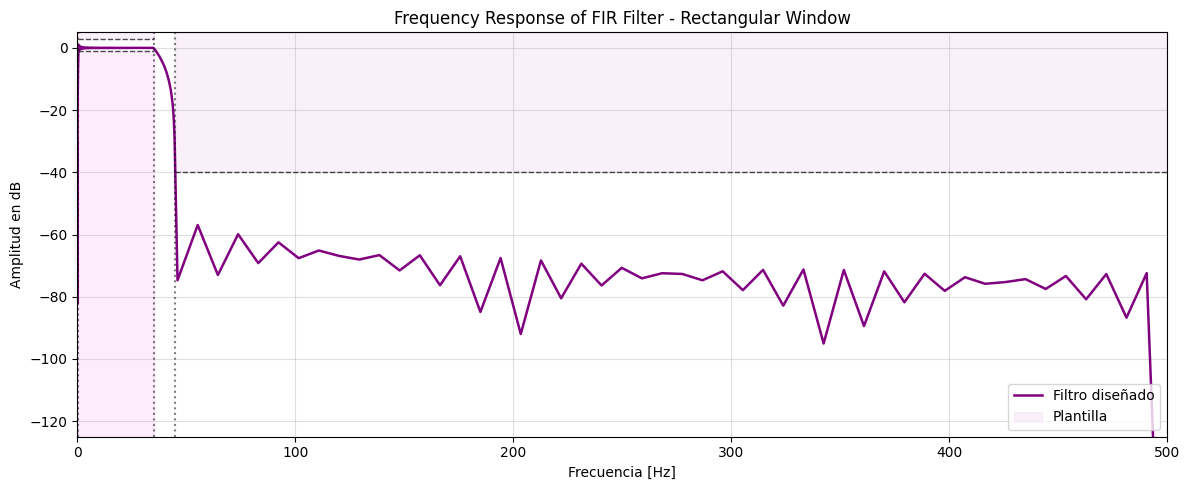


INFORMACION DEL FIR
--------------------------------
Ventana usada: boxcar / rectangular
Cantidad de coeficientes: 2000
Orden del filtro: 1999
Retardo teorico: 999.5 muestras
Tipo de FIR: Tipo 2
Retardo: no entero
Cero obligatorio en Nyquist
--------------------------------


In [5]:
#%% Diseno de FIR con ventana rectangular

numtaps = 2000

gains = np.array([0, 0, 1, 1, 0, 0])

ws1b = 0.2     # Banda de stop baja
wp1b = 0.5      # Inicio banda de paso
wp2b = 35       # Fin banda de paso
ws2b = 45       # Banda de stop alta

b_win = sig.firwin2(
    numtaps,
    freq=np.array([0., ws1b, wp1b, wp2b, ws2b, fs/2]),
    gain=gains,
    window='boxcar',
    fs=fs
)

# Respuesta en frecuencia del FIR
w, h = sig.freqz(b_win, worN=ww, fs=fs)

modulo_db = 20 * np.log10(np.abs(h) + 1e-12)


#%% Grafico con plantilla de diseño sombreada

fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)

ax1.set_title("Frequency Response of FIR Filter - Rectangular Window")

ax1.plot(w, modulo_db, 'purple', linewidth=1.8, label='Filtro diseñado')

piso_grafico = -125
techo_grafico = 5

# Banda de parada baja
ax1.fill_between(
    [0, ws1],
    -gstop,
    techo_grafico,
    color='plum',
    alpha=0.15,
    label='Plantilla'
)

ax1.plot(
    [0, ws1],
    [-gstop, -gstop],
    'k--',
    linewidth=1,
    alpha=0.7
)

# Banda de paso
ax1.fill_between(
    [wp1, wp2],
    piso_grafico,
    -gpass,
    color='violet',
    alpha=0.15
)

ax1.plot(
    [wp1, wp2],
    [-gpass, -gpass],
    'k--',
    linewidth=1,
    alpha=0.7
)

# Zona superior banda de paso
ax1.fill_between(
    [wp1, wp2],
    3,
    techo_grafico,
    color='plum',
    alpha=0.15
)

ax1.plot(
    [wp1, wp2],
    [3, 3],
    'k--',
    linewidth=1,
    alpha=0.7
)

# Banda de parada alta
ax1.fill_between(
    [ws2, fs/2],
    -gstop,
    techo_grafico,
    color='plum',
    alpha=0.15
)

ax1.plot(
    [ws2, fs/2],
    [-gstop, -gstop],
    'k--',
    linewidth=1,
    alpha=0.7
)

# Lineas verticales
ax1.axvline(ws1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp2, color='k', linestyle=':', alpha=0.5)
ax1.axvline(ws2, color='k', linestyle=':', alpha=0.5)

ax1.set_ylabel("Amplitud en dB")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_xlim(0, fs/2)
ax1.set_ylim([piso_grafico, techo_grafico])
ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')

plt.show()


#%% Informacion del filtro FIR

print("")
print("INFORMACION DEL FIR")
print("--------------------------------")
print("Ventana usada: boxcar / rectangular")
print("Cantidad de coeficientes:", numtaps)
print("Orden del filtro:", numtaps - 1)
print("Retardo teorico:", (numtaps - 1) / 2, "muestras")

if numtaps % 2 == 0:
    print("Tipo de FIR: Tipo 2")
    print("Retardo: no entero")
    print("Cero obligatorio en Nyquist")
else:
    print("Tipo de FIR: Tipo 1")
    print("Retardo: entero")

print("--------------------------------")


### c.4) Carga del ECG

Se carga la señal de ECG desde el archivo `.mat`. La señal fue registrada a **fs = 1000 Hz** durante una prueba de esfuerzo, lo que la hace particularmente susceptible a ruido muscular y de movimiento de electrodos.


In [6]:
#%% Cargar ECG

fs_ecg = 1000  # Hz

# Para listar las variables que hay en el archivo
# sio.whosmat('ECG_TP4.mat')

mat_struct = sio.loadmat('/home/miranda/analisis_senales/ecg.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()

cant_muestras = len(ecg_one_lead)

print("")
print("INFORMACION ECG")
print("--------------------------------")
print("Cantidad de muestras:", cant_muestras)
print("Frecuencia de muestreo ECG:", fs_ecg, "Hz")
print("--------------------------------")



INFORMACION ECG
--------------------------------
Cantidad de muestras: 1129116
Frecuencia de muestreo ECG: 1000 Hz
--------------------------------


### c.5) Aplicación de los filtros al ECG

Se aplican los dos filtros al ECG:
- **Butterworth IIR** con `sosfiltfilt` → **fase cero**, sin retardo.
- **FIR ventana rectangular** con `lfilter` → **causal**, introduce un retardo de `(numtaps-1)/2` muestras que se compensa al graficar.


In [7]:
#%% Procesar el ECG

# Butterworth con filtfilt: no queda corrido porque filtra ida y vuelta
ECG_f_butt = sig.sosfiltfilt(sos_but, ecg_one_lead)

# FIR Window con lfilter: queda demorado porque es causal
ECG_f_wh = sig.lfilter(b_win, 1, ecg_one_lead)

# Demora del FIR
# Para FIR de fase lineal: demora = (numtaps - 1)/2
demora = int((numtaps - 1) / 2)

print(f"Retardo del FIR compensado: {demora} muestras ({demora/fs_ecg*1000:.1f} ms)")


Retardo del FIR compensado: 999 muestras (999.0 ms)


## d) Evaluación del rendimiento de los filtros

### d.1) Regiones con ruido (alta frecuencia + deriva de línea de base)

Las siguientes regiones del ECG presentan contaminación visible. Se observa cómo ambos filtros eliminan eficazmente el ruido de alta frecuencia y la deriva de la línea de base, permitiendo observar con claridad la morfología del latido (onda P, complejo QRS, onda T).

El **Butterworth** (línea rosada) no presenta retardo. El **FIR ventana** (línea roja oscura) se grafica con compensación de retardo (`zoom_region + demora`), por lo que también queda alineado.


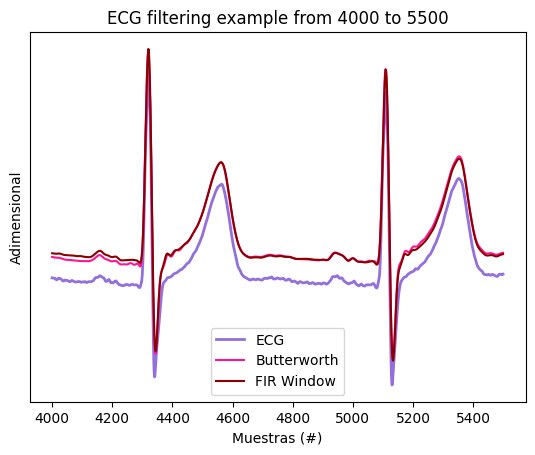

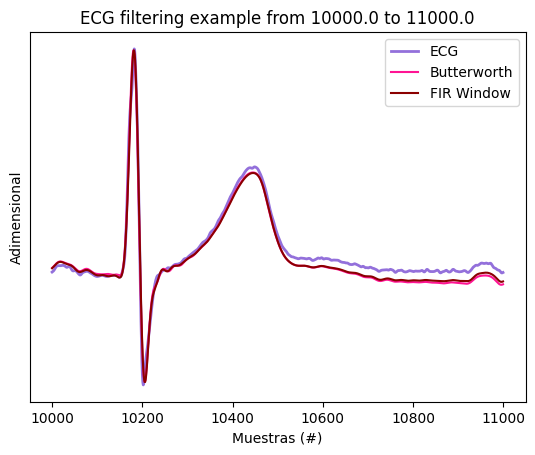

In [8]:
###################################
#%% Regiones de interes con ruido #
###################################

regs_interes = (
        [4000, 5500],     # muestras
        [10e3, 11e3],     # muestras
        )

for ii in regs_interes:

    zoom_region = np.arange(
        np.max([0, ii[0]]),
        np.min([cant_muestras - demora, ii[1]]),
        dtype='uint'
    )

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], color='mediumpurple' , label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], color='deeppink' , label='Butterworth')
    plt.plot(zoom_region, ECG_f_wh[zoom_region + demora], color='darkred' ,label='FIR Window')

    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')

    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())

    plt.show()


### d.2) Regiones sin ruido (zona limpia)

En estas regiones el ECG original ya presenta buena calidad. Se verifica que los filtros son **inocuos**: no distorsionan la morfología del latido ni introducen artefactos. Ambas señales filtradas deben superponerse fielmente al ECG original.

Las tres regiones se expresan en minutos y se convierten a muestras. Corresponden a segmentos tranquilos donde el nivel de ruido es bajo.


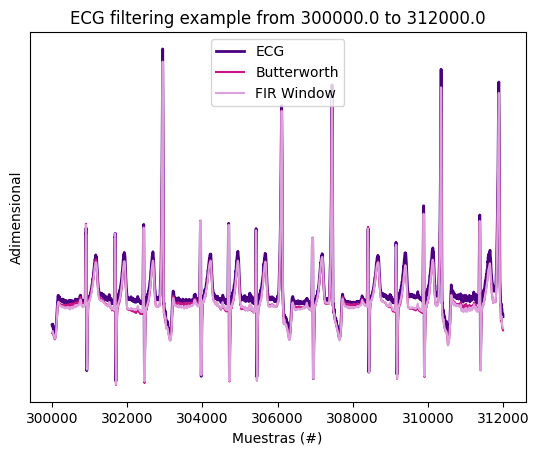

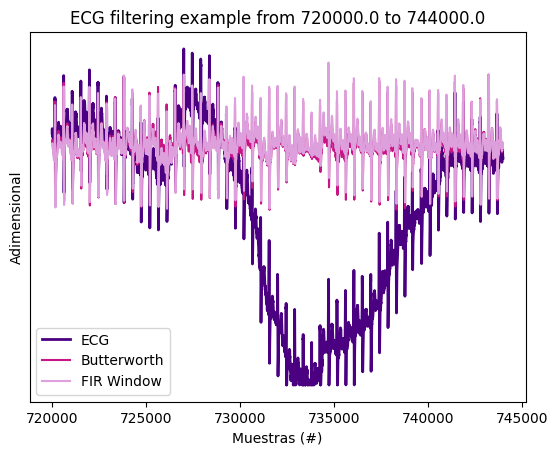

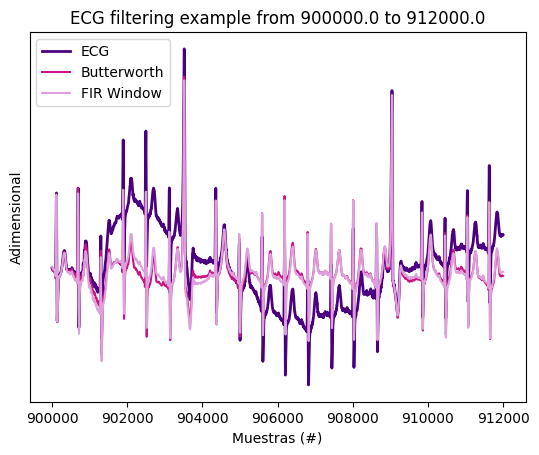

In [9]:
###################################
#%% Regiones de interes sin ruido #
###################################

regs_interes = (
        np.array([5, 5.2]) * 60 * fs_ecg,     # minutos a muestras
        np.array([12, 12.4]) * 60 * fs_ecg,   # minutos a muestras
        np.array([15, 15.2]) * 60 * fs_ecg,   # minutos a muestras
        )

for ii in regs_interes:

    zoom_region = np.arange(
        np.max([0, ii[0]]),
        np.min([cant_muestras - demora, ii[1]]),
        dtype='uint'
    )

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], color='indigo' , label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], color='mediumvioletred' , label='Butterworth')
    plt.plot(zoom_region, ECG_f_wh[zoom_region + demora], color='plum' , label='FIR Window')

    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')

    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())

    plt.show()


### d.3) Filtro FIR – Cuadrados Mínimos (`firls`)

El método de **cuadrados mínimos** minimiza el error cuadrático medio entre la respuesta deseada y la obtenida. A diferencia de la ventana rectangular, permite asignar **pesos** a cada banda, priorizando el cumplimiento en la banda de stop baja (peso 2 vs. 1 para las demás), lo que reduce la deriva de línea de base residual.

Se usa `numtaps = 2001` (impar → FIR Tipo 1, retardo entero).


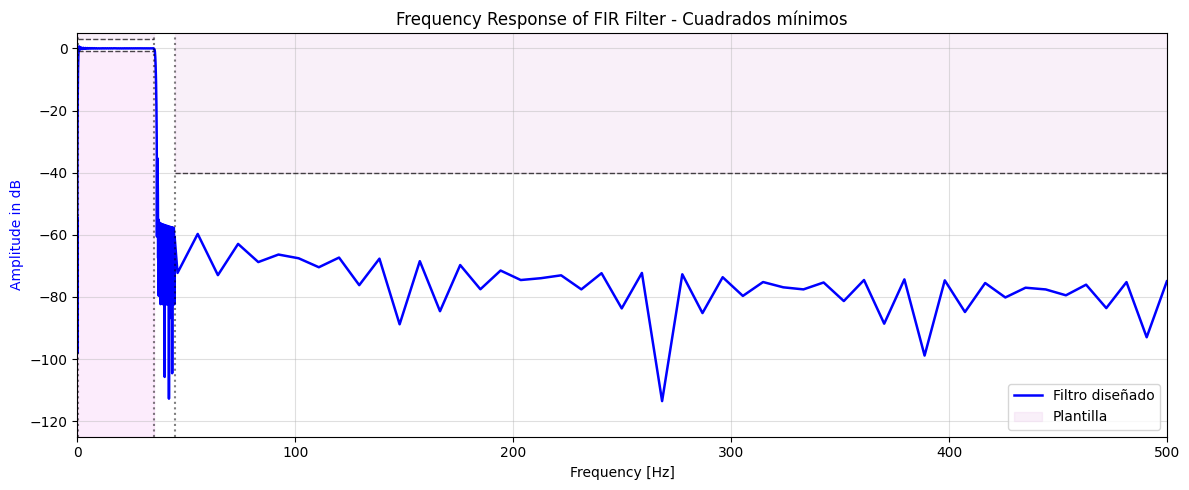

In [10]:
    #%% FILTRO FIR CON CUADRADOS MINIMOS 
    ws1c = 0.126     # Banda de stop baja
    wp1c = 0.5      # Inicio banda de paso
    wp2c = 35       # Fin banda de paso
    ws2c = 37       # Banda de stop alta
    
    numtapsc = 2001
    
    weight = np.array([2,1,1])
    b_cuadradosmin = sig.firls (numtapsc , bands =np.array([0., ws1c, wp1c, wp2c, ws2c, fs/2]), desired=[0, 0, 1, 1, 0, 0], weight = weight, fs = fs ) 
    # Respuesta en frecuencia del FIR
    wc, hc = sig.freqz(b_cuadradosmin, worN=ww, fs=fs)

    modulo_dbc = 20 * np.log10(np.abs(hc) + 1e-12)


    #%% Grafico con plantilla de diseño sombreada

    fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)

    ax1.set_title("Frequency Response of FIR Filter - Cuadrados mínimos")

    ax1.plot(wc, modulo_dbc, 'b', linewidth=1.8, label='Filtro diseñado')

    piso_grafico = -125
    techo_grafico = 5

    # Banda de parada baja
    ax1.fill_between(
        [0, ws1],
        -gstop,
        techo_grafico,
        color='plum',
        alpha=0.15,
        label='Plantilla'
    )

    ax1.plot(
        [0, ws1],
        [-gstop, -gstop],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Banda de paso
    ax1.fill_between(
        [wp1, wp2],
        piso_grafico,
        -gpass,
        color='violet',
        alpha=0.15
    )

    ax1.plot(
        [wp1, wp2],
        [-gpass, -gpass],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Zona superior banda de paso
    ax1.fill_between(
        [wp1, wp2],
        3,
        techo_grafico,
        color='plum',
        alpha=0.15
    )

    ax1.plot(
        [wp1, wp2],
        [3, 3],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Banda de parada alta
    ax1.fill_between(
        [ws2, fs/2],
        -gstop,
        techo_grafico,
        color='plum',
        alpha=0.15
    )

    ax1.plot(
        [ws2, fs/2],
        [-gstop, -gstop],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Lineas verticales
    ax1.axvline(ws1, color='k', linestyle=':', alpha=0.5)
    ax1.axvline(wp1, color='k', linestyle=':', alpha=0.5)
    ax1.axvline(wp2, color='k', linestyle=':', alpha=0.5)
    ax1.axvline(ws2, color='k', linestyle=':', alpha=0.5)

    ax1.set_ylabel("Amplitude in dB", color='b')
    ax1.set_xlabel("Frequency [Hz]")
    ax1.set_xlim(0, fs/2)
    ax1.set_ylim([piso_grafico, techo_grafico])
    ax1.grid(True, which='both', linestyle='-', alpha=0.4)
    ax1.legend(loc='lower right')

    plt.show()


### d.4) Filtro FIR – Parks-McClellan / Remez (`remez`)

El algoritmo de **Parks-McClellan** (también llamado Remez o equiripple) diseña el filtro FIR de **mínimo orden** que cumple una especificación dada, distribuyendo el error de forma equiripple (uniforme) en las bandas. Esto lo hace más eficiente en orden que el método de ventana o cuadrados mínimos para una misma especificación.

El parámetro `type='hilbert'` se utiliza aquí para garantizar antisimetría de los coeficientes y permitir el diseño pasa-banda con `desired=[0, 1, 0]`. Se especifica `maxiter=25` y `grid_density=16` para mejorar la convergencia.


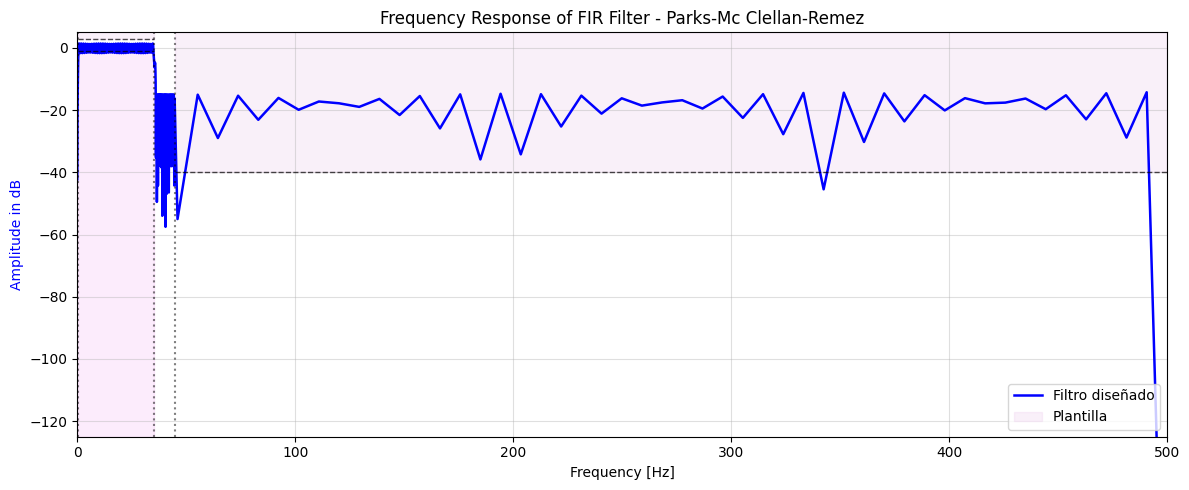

In [11]:
    #%%  FILTRO FIR CON Parks-Mc Clellan-Remez
    ws1r = 0.126     # Banda de stop baja
    wp1r = 0.5      # Inicio banda de paso
    wp2r = 35       # Fin banda de paso
    ws2r = 36       # Banda de stop alta
    
    numtapsr = 2001
    
    weightr = np.array([2,1,1])
    b_remez = sig.remez (numtapsr , bands =np.array([0., ws1r, wp1r, wp2r, ws2r, fs/2]), desired=[0, 1, 0], weight = weightr, type='hilbert', maxiter=25, grid_density=16, fs = fs ) 
    # Respuesta en frecuencia del FIR
    wr, hr = sig.freqz(b_remez, worN=ww, fs=fs)

    modulo_dbr = 20 * np.log10(np.abs(hr) + 1e-12)


    #%% Grafico con plantilla de diseño sombreada

    fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)

    ax1.set_title("Frequency Response of FIR Filter - Parks-Mc Clellan-Remez")

    ax1.plot(wr, modulo_dbr, 'b', linewidth=1.8, label='Filtro diseñado')

    piso_grafico = -125
    techo_grafico = 5

    # Banda de parada baja
    ax1.fill_between(
        [0, ws1],
        -gstop,
        techo_grafico,
        color='plum',
        alpha=0.15,
        label='Plantilla'
    )

    ax1.plot(
        [0, ws1],
        [-gstop, -gstop],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Banda de paso
    ax1.fill_between(
        [wp1, wp2],
        piso_grafico,
        -gpass,
        color='violet',
        alpha=0.15
    )

    ax1.plot(
        [wp1, wp2],
        [-gpass, -gpass],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Zona superior banda de paso
    ax1.fill_between(
        [wp1, wp2],
        3,
        techo_grafico,
        color='plum',
        alpha=0.15
    )

    ax1.plot(
        [wp1, wp2],
        [3, 3],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Banda de parada alta
    ax1.fill_between(
        [ws2, fs/2],
        -gstop,
        techo_grafico,
        color='plum',
        alpha=0.15
    )

    ax1.plot(
        [ws2, fs/2],
        [-gstop, -gstop],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Lineas verticales
    ax1.axvline(ws1, color='k', linestyle=':', alpha=0.5)
    ax1.axvline(wp1, color='k', linestyle=':', alpha=0.5)
    ax1.axvline(wp2, color='k', linestyle=':', alpha=0.5)
    ax1.axvline(ws2, color='k', linestyle=':', alpha=0.5)

    ax1.set_ylabel("Amplitude in dB", color='b')
    ax1.set_xlabel("Frequency [Hz]")
    ax1.set_xlim(0, fs/2)
    ax1.set_ylim([piso_grafico, techo_grafico])
    ax1.grid(True, which='both', linestyle='-', alpha=0.4)
    ax1.legend(loc='lower right')

    plt.show()


---

## Conclusiones

- Todos los filtros diseñados a partir de modificar sus propios limites distintos a los de la plantilla principal, cumplen la plantilla de diseño pasa-banda (0.5–35 Hz), eliminando tanto la deriva de línea de base como el ruido de alta frecuencia.
- El **Butterworth IIR** logra el cumplimiento de la plantilla con el menor número de coeficientes, pero su fase no lineal es compensada por el uso de `sosfiltfilt`.
- Los **FIR** tienen fase lineal intrínseca (retardo de grupo constante), lo que preserva mejor la morfología relativa de las ondas, a costa de usar ~2000 coeficientes.
- El método de **cuadrados mínimos** y **Parks-McClellan** permiten mayor control sobre la distribución del error en cada banda y pueden lograr mejores prestaciones en bandas de stop con el mismo orden de filtro que la ventana rectangular.
- En las regiones de ECG limpio, todos los filtros son inocuos y no distorsionan la morfología del latido.
